# Baseline e Modelação

> Objetivo: construir e avaliar três modelos baseline em ordem: Regressão Logística, Árvore de Decisão e Random Forest.

## Estrutura desta secção
1. Preparação dos dados
2. Baseline: Regressão Logística
3. Baseline: Árvore de Decisão
4. Baseline: Random Forest

In [88]:
# importações de bibliotecas
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

ortho_clean = pd.read_csv('ortho_eda_clean.csv')

In [103]:
#alteração do tipo de dados das variáveis "Grupo_pre" e "Sexo" para category
ortho_clean["Grupo_pre"] = ortho_clean["Grupo_pre"].astype("category")
ortho_clean["Sexo"] = ortho_clean["Sexo"].astype("category")
ortho_clean["mudanca_CPAK"] = ortho_clean["mudanca_CPAK"].astype("category")


# one hot encoding apenas para "grupo_pre" pois apresenta mais de 2 categorias
categorical_features = ["Grupo_pre"]
ortho_clean = pd.get_dummies(ortho_clean, columns=categorical_features, drop_first=True)



In [105]:
ortho_clean.head()

,Idade,Sexo,Peso,Altura_cm,IMC,Fle_0,EVA_0,PM6_0,WD_0,WR_0,...,WT_0,mudanca_CPAK,Grupo_pre_2,Grupo_pre_3,Grupo_pre_4,Grupo_pre_5,Grupo_pre_6,Grupo_pre_7,Grupo_pre_8,Grupo_pre_9
0,67,0,80.0,158.0,32.046146,86.0,4.0,324.0,15,6.0,...,75,False,False,False,False,True,False,False,False,False
1,76,1,60.0,155.0,24.973985,90.0,4.0,357.0,14,7.0,...,60,False,False,False,False,True,False,False,False,False
2,72,1,93.0,182.0,28.076319,45.0,10.0,289.0,15,4.0,...,72,False,False,False,False,False,False,False,False,False
3,67,1,71.0,163.0,26.722873,127.0,2.0,390.0,1,1.0,...,18,False,False,False,False,False,True,False,False,False
4,66,0,49.0,160.0,19.140625,120.0,0.0,285.0,0,0.0,...,8,False,False,False,False,False,True,False,False,False


## 1) Preparação dos dados

Nesta fase convertemos Grupo_pre e Sexo para categóricas, definimos X_raw e y, fazemos o split estratificado e aplicamos one-hot encoding para todos os modelos baseline.

In [106]:
#definição de X e y para a modelação

X = ortho_clean.drop("mudanca_CPAK", axis=1)
y = ortho_clean["mudanca_CPAK"]



In [107]:
# Verificação de valores nulos em X
X.isnull().sum()

Idade          0
Sexo           0
Peso           0
Altura_cm      0
IMC            0
Fle_0          0
EVA_0          0
PM6_0          0
WD_0           0
WR_0           0
WAtotal_0      0
WT_0           0
Grupo_pre_2    0
Grupo_pre_3    0
Grupo_pre_4    0
Grupo_pre_5    0
Grupo_pre_6    0
Grupo_pre_7    0
Grupo_pre_8    0
Grupo_pre_9    0
dtype: int64

In [108]:
# Verificação de valores nulos em y
y.isnull().sum()

np.int64(0)

In [109]:
# Split estratificado dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)



In [110]:
# Verificação da distribuição da target no conjunto de treino
print("Distribuição da Target (CPAK) - Treino")
print("N. observações Treino", len(X_train))
print(y_train.value_counts(normalize=True))

Distribuição da Target (CPAK) - Treino
N. observações Treino 183
mudanca_CPAK
False    0.901639
True     0.098361
Name: proportion, dtype: float64


In [111]:
# Verificação da distribuição da target no conjunto de teste

print("Distribuição da Target (CPAK) - Teste")
print("N. observações Teste", len(X_test))
print(y_test.value_counts(normalize=True))

Distribuição da Target (CPAK) - Teste
N. observações Teste 79
mudanca_CPAK
False    0.898734
True     0.101266
Name: proportion, dtype: float64


# 2) Obtenção de Baseline: Regressão logistica, Árvore de decisão e Random forest


## 2.1) Baseline: Regressão Logística

Treino do modelo baseline de regressão logística e avaliação com métricas de classificação.

In [117]:
# Treino do baseline com Regressão Logística
clf_LR = LogisticRegression(random_state=42)
clf_LR = clf_LR.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_LR = clf_LR.predict(X_test)
y_pred_LR_prob = clf_LR.predict_proba(X_test)
print(y_pred_LR_prob)
print(y_pred_LR)

[[9.93630627e-01 6.36937279e-03]
 [9.95410805e-01 4.58919483e-03]
 [9.99755509e-01 2.44491202e-04]
 [9.63996664e-01 3.60033359e-02]
 [9.93304308e-01 6.69569186e-03]
 [9.91663028e-01 8.33697246e-03]
 [9.57802531e-01 4.21974687e-02]
 [9.95710518e-01 4.28948198e-03]
 [2.36359293e-01 7.63640707e-01]
 [8.43238675e-01 1.56761325e-01]
 [9.99621647e-01 3.78352710e-04]
 [8.82172800e-01 1.17827200e-01]
 [9.95079812e-01 4.92018820e-03]
 [9.99344093e-01 6.55906553e-04]
 [9.97868052e-01 2.13194775e-03]
 [9.97563543e-01 2.43645660e-03]
 [8.74773751e-01 1.25226249e-01]
 [9.92756145e-01 7.24385518e-03]
 [9.99984494e-01 1.55062979e-05]
 [9.98900344e-01 1.09965643e-03]
 [9.73063337e-01 2.69366629e-02]
 [9.99941554e-01 5.84457627e-05]
 [5.82565053e-01 4.17434947e-01]
 [9.82146494e-01 1.78535063e-02]
 [9.37540677e-01 6.24593226e-02]
 [9.94989258e-01 5.01074176e-03]
 [9.84658638e-01 1.53413616e-02]
 [9.96635469e-01 3.36453062e-03]
 [9.87869169e-01 1.21308309e-02]
 [2.31480332e-01 7.68519668e-01]
 [9.185263

c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


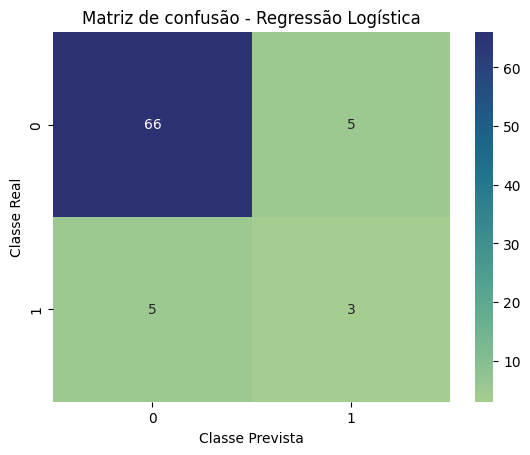

In [118]:
# Matriz de confusão do baseline (Regressão Logística)
c_matrix_LR = confusion_matrix(y_test, y_pred_LR)


# Visualização da matriz de confusão
sns.heatmap(c_matrix_LR, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.title("Matriz de confusão - Regressão Logística")
plt.show()

In [119]:
# Relatório de classificação do baseline
print(classification_report(y_test, y_pred_LR))

              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93        71
         1.0       0.38      0.38      0.38         8

    accuracy                           0.87        79
   macro avg       0.65      0.65      0.65        79
weighted avg       0.87      0.87      0.87        79



In [120]:
# Área sob a curva ROC (AUC)
auc = roc_auc_score(y_test, y_pred_LR)
print("AUC:", auc)

AUC: 0.6522887323943661


In [121]:
# validação( stratified k-fold) para estimar a performance do modelo de Regressão Logística

pred_cross_LR_strat = cross_val_predict(clf_LR, X, y, cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle = True,random_state=42))

print(classification_report(y, pred_cross_LR_strat, digits=4))

              precision    recall  f1-score   support

         0.0     0.9106    0.9492    0.9295       236
         1.0     0.2500    0.1538    0.1905        26

    accuracy                         0.8702       262
   macro avg     0.5803    0.5515    0.5600       262
weighted avg     0.8450    0.8702    0.8561       262



c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

In [28]:
coeficientes_lr = pd.DataFrame({
    "Variavel": X_train.columns,
    "Coeficiente": clf_LR.coef_[0]
})

coeficientes_lr["Abs_Coeficiente"] = coeficientes_lr["Coeficiente"].abs()
coeficientes_lr.sort_values(by="Abs_Coeficiente", ascending=False)

,Variavel,Coeficiente,Abs_Coeficiente
4,IMC,-0.165150,0.165150
10,WR_0,0.093302,0.093302
0,Idade,-0.089922,0.089922
9,WD_0,-0.061201,0.061201
6,Fle_0,0.056362,0.056362
2,Peso,-0.046823,0.046823
7,EVA_0,0.035276,0.035276
12,WT_0,0.033650,0.033650
1,Sexo,-0.018066,0.018066
8,PM6_0,0.012834,0.012834


## 2.2) Baseline: Decision Tree

Obtenção de Baselin de um modelo de árvore de decisão e avaliação com métricas de classificação.

In [29]:
# Treino do baseline com Árvore de Decisão
clf_DT = tree.DecisionTreeClassifier(random_state=42)
clf_DT = clf_DT.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_DT = clf_DT.predict(X_test)
y_pred_DT

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

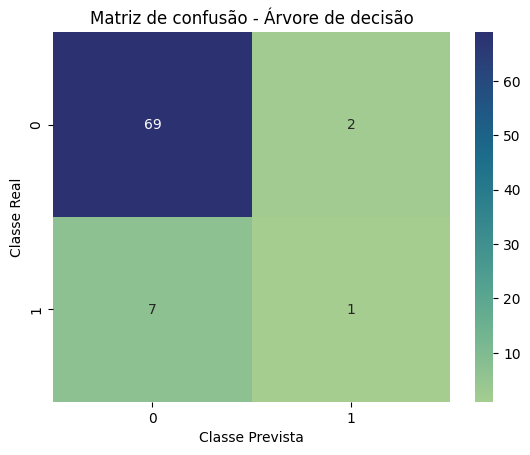

In [30]:
# Matriz de confusão do baseline (Árvore de Decisão)
confusion_m = confusion_matrix(y_test, y_pred_DT)

# Visualização da matriz de confusão
sns.heatmap(confusion_m, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.title("Matriz de confusão - Árvore de decisão")
plt.show()

In [54]:
# Relatório de classificação do baseline
print(classification_report(y_test, y_pred_DT))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94        71
           1       0.33      0.12      0.18         8

    accuracy                           0.89        79
   macro avg       0.62      0.55      0.56        79
weighted avg       0.85      0.89      0.86        79



In [31]:
# Área sob a curva ROC (AUC)
auc = roc_auc_score(y_test, y_pred_DT)
print("AUC:", auc)

AUC: 0.5484154929577465


In [55]:
# validação( stratified k-fold) para estimar a performance do modelo de Decision Tree

pred_cross_DT_strat = cross_val_predict(clf_DT, X, y, cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

print(classification_report(y, pred_cross_DT_strat, digits=4))

              precision    recall  f1-score   support

         0.0     0.9149    0.9110    0.9130       236
         1.0     0.2222    0.2308    0.2264        26

    accuracy                         0.8435       262
   macro avg     0.5686    0.5709    0.5697       262
weighted avg     0.8462    0.8435    0.8448       262



## 2.3) Baseline: Random Forest

Obtenção de baseline de um modelo de Random forest e avaliação com métricas de classificação.

In [39]:
# Treino do baseline com Random Forest
clf_RF = RandomForestClassifier(random_state=42)
clf_RF = clf_RF.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_RF = clf_RF.predict(X_test)
print(y_pred_RF)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0.]


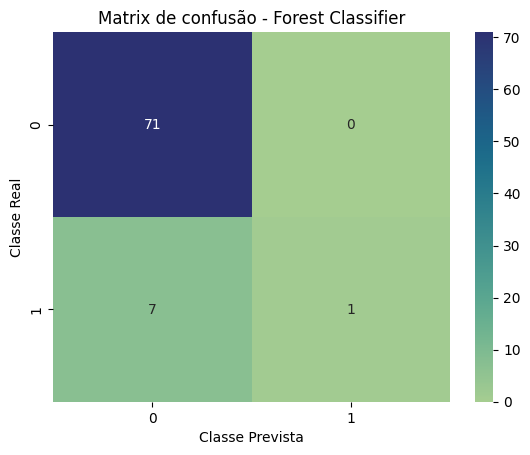

In [40]:
# matriz de confusão
confusion_matrix_RF = confusion_matrix(y_test, y_pred_RF)

#gráfico de matriz de confusão
sns.heatmap(confusion_matrix_RF, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.title("Matrix de confusão - Forest Classifier")
plt.show()

In [41]:
print(classification_report(y_test, y_pred_RF))

              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95        71
         1.0       1.00      0.12      0.22         8

    accuracy                           0.91        79
   macro avg       0.96      0.56      0.59        79
weighted avg       0.92      0.91      0.88        79



In [42]:
#Area Under the Curve (AUC)
auc = roc_auc_score(y_test, y_pred_RF)
print("AUC:", auc)

AUC: 0.5625


In [56]:
# validação( stratified k-fold) para estimar a performance do modelo de Random Forest

pred_cross_RF_strat = cross_val_predict(clf_RF, X, y, cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle = True, random_state=42))

print(classification_report(y, pred_cross_RF_strat, digits=4))

              precision    recall  f1-score   support

         0.0     0.9073    0.9958    0.9495       236
         1.0     0.6667    0.0769    0.1379        26

    accuracy                         0.9046       262
   macro avg     0.7870    0.5363    0.5437       262
weighted avg     0.8835    0.9046    0.8690       262



# 3) tuning de Regressão logistica


Após avaliação das métricas de baseline optámos por desenvolver o modelo de Regressão logistica pois apresenta melhores valores baseline, e apesar de baixarm um pouco após K-fold
Este modelo tambem apresenta uma maior facilidade de explicabilidade